# **FICO® Xpress MoselPy - Chapter H: Economics and Finance**

***economics_finance.ipynb*** - Economics and finance problems from the Xpress Applications Book - loan selection, publicity planning, portfolio composition, retirement funding, family budgeting, company expansion, and quadratic mean-variance portfolio selection, solved with MoselPy.

&copy; Copyright 2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/xpress-community#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q moselpy mosellibs xpresslibs matplotlib pandas

Run the cell below to import the necessary libraries and set `MODELS` and `DATA`, the path variables pointing to the Mosel model files and data files used in this notebook.

In [ ]:
# On Linux, preload the Xpress solver library so the Mosel optimizer module
# (mmxprs) can resolve it at runtime.
import sys, os, glob, ctypes, xpresslibs
if sys.platform == "linux":
    for _lib in glob.glob(os.path.join(xpresslibs.solver_libs_dir, "libxprs.so*")):
        ctypes.CDLL(_lib, mode=ctypes.RTLD_GLOBAL)

import moselpy as mp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

MODELS = "models/economics_finance"
DATA   = "data/economics_finance"

print(f"MoselPy {mp.version}  |  Mosel {mp.mosel_version}  |  Xpress {mp.xpress_version}")
mp.config.set_default_stream(mp.StreamType.OUTPUT, "null:")

MoselPy 6.12.0  |  Mosel 6012000  |  Xpress 10000000


## Economics and finance problems

This notebook covers seven LP, MIP, and QP examples from Chapter H of the Xpress Applications Book, solved via [MoselPy](https://pypi.org/project/moselpy/). Examples range from loan selection and publicity planning to portfolio optimization, retirement fund design, family budgeting, company expansion, and quadratic mean-variance portfolio selection.

> **Mosel source files:** [`models/economics_finance/`](models/economics_finance/) &nbsp;|&nbsp; **Data files:** [`data/economics_finance/`](data/economics_finance/)

> **Requirements:** `pip install moselpy mosellibs xpresslibs` - `mosellibs` provides the Mosel runtime and `xpresslibs` the Xpress solver libraries. No local Xpress installation is needed to run these notebooks, as long as the packages with libraries have been installed.

> A local FICO&reg; Xpress installation is recommended if you want access to the full set of examples, user guides and documentation, solver libraries, and Xpress Workbench. Obtain one via the [FICO&reg; Xpress community license](https://www.fico.com/en/fico-xpress-community-license) page. If a local installation is present, set `XPRESSDIR` before starting Jupyter to use it instead of the `mosellibs` and `xpresslibs` packages.

> **MoselPy documentation:** [MoselPy User Guide and Reference Manual](https://www.fico.com/fico-xpress-optimization/docs/latest/mosel/MoselPy/dhtml)

> **Mosel examples on the web:** [examples.xpress.fico.com](https://examples.xpress.fico.com/example.pl?id=mosel_app_8)

### MoselPy features demonstrated in this chapter

- **String-keyed dict input**: H-1 populates the `SHOPS` set automatically from `PRICE` dict keys; no need to pass the set separately.
- **`exec_params` to override model parameters**: H-2 controls `BUDGET` and `TARGET`; H-3 controls portfolio composition limits from Python without editing the model.
- **`set of integer` passed from Python**: H-3 passes `EU` and `TECHNOLOGY` directly as Python `set` objects.
- **Solving as an LP via `XPRS_LIN`**: H-6 calls `maximize(XPRS_LIN, Profit)` to solve the problem first as an LP, ignoring any MIP information, then `maximize(Profit)` for the full MIP.
- **`mmnl` module for quadratic objectives**: H-7 uses the Mosel nonlinear module for mean-variance QP and MIQP.
- **Efficient frontier sensitivity**: H-7 varies the `TARGET` yield across a parametric loop and collects variance vs return into a `pd.DataFrame`.

## H-1 Loan choice (LP)

*Applications Book Chapter H, Example 1*

> **Mosel model:** [`h1loan_p.mos`](models/economics_finance/h1loan_p.mos)

A chain of shops aims to open three new shops in London, Munich, and Rome. Three banks offer loans at different interest rates for each project, with a common maximum total loan volume. The model minimizes total annual interest payments over an 8-year repayment period.

**Sets:** $\text{BANKS} = \{1,2,3\}$, $\text{SHOPS} = \{\text{London},\text{Munich},\text{Rome}\}$

**Parameters:** $\text{PRICE}_s$ - opening cost of shop $s$; $\text{RATE}_{b,s}$ - annual rate of bank $b$ for shop $s$; $\text{VMAX}$ - max total loan per bank; $\text{DUR}$ - repayment period

**Decision variables:** $\mathit{borrow}_{b,s} \geq 0$ - loan from bank $b$ for shop $s$

$$
\begin{align*}
\text{minimize}   \quad & \sum_{b,s} \mathit{borrow}_{b,s} \cdot \frac{\text{RATE}_{b,s}}{1-(1+\text{RATE}_{b,s})^{-\text{DUR}}} \\
\text{subject to} \quad & \sum_b \mathit{borrow}_{b,s} = \text{PRICE}_s \quad \forall\, s \\
                          & \sum_s \mathit{borrow}_{b,s} \leq \text{VMAX} \quad \forall\, b
\end{align*}
$$

Define the shop prices as a string-keyed dict and the rate matrix as a dict with `(bank, shop)` tuple keys. Passing `PRICE` via `input_data` automatically populates the `SHOPS` set of strings in the Mosel model from the dict keys. The scalar parameters `DUR` and `VMAX` are already set as model defaults and can be overridden via `exec_params`.

In [ ]:
PRICE = {"London": 2_500_000, "Munich": 1_000_000, "Rome": 1_700_000}

RATE = {
    (1, "London"): 0.050, (1, "Munich"): 0.065, (1, "Rome"): 0.061,
    (2, "London"): 0.052, (2, "Munich"): 0.062, (2, "Rome"): 0.062,
    (3, "London"): 0.055, (3, "Munich"): 0.058, (3, "Rome"): 0.065,
}

shops = list(PRICE.keys())
banks = [1, 2, 3]

rate_df = pd.DataFrame(
    {s: [RATE[(b, s)] * 100 for b in banks] for s in shops},
    index=[f"Bank {b}" for b in banks],
)
rate_df.index.name = "Bank"
print(f"Shop prices: { {s: f'{v:,.0f}' for s,v in PRICE.items()} }")
print(f"\nInterest rates (%):")
print(rate_df.to_string())

Shop prices: {'London': '2,500,000', 'Munich': '1,000,000', 'Rome': '1,700,000'}

Interest rates (%):
        London  Munich  Rome
Bank                        
Bank 1     5.0     6.5   6.1
Bank 2     5.2     6.2   6.2
Bank 3     5.5     5.8   6.5


Use the single execution command. The `SHOPS` set of strings auto-populates from the `PRICE` dict keys. After solving, `sol_borrow` is a dict with `(bank, shop)` tuple keys.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/h1loan_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"PRICE": PRICE, "RATE": RATE},
)

if model.prob_status.is_solution_available:
    obj_val_h1  = output["obj_val"]
    sol_borrow  = output["sol_borrow"]

    print(f"Total annual interest: {obj_val_h1:,.2f}")
    print()
    for s in shops:
        loans = {b: sol_borrow.get((b, s), 0) for b in banks if sol_borrow.get((b, s), 0) > 0.5}
        parts = [f"bank {b}: {v/1e6:.2f}M" for b, v in loans.items()]
        print(f"  {s}: {', '.join(parts)}")
else:
    print(f"No solution found ({model.prob_status})")

Total annual interest: 822,180.66

  London: bank 1: 2.50M
  Munich: bank 3: 1.00M
  Rome: bank 1: 0.50M, bank 2: 1.20M


Stacked bar chart showing the loan split per shop across the three banks.

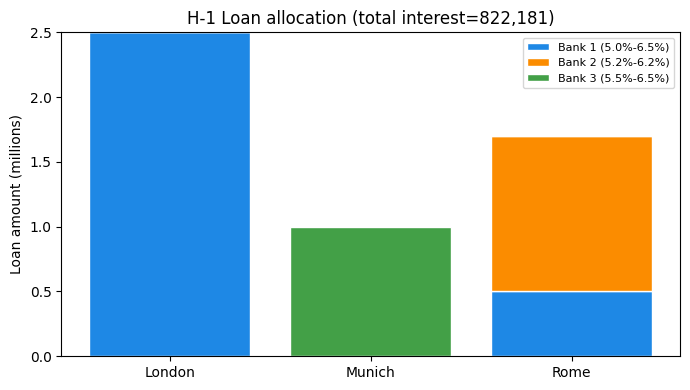

In [ ]:
if "sol_borrow" in locals():
    bank_colors = {1: "#1E88E5", 2: "#FB8C00", 3: "#43A047"}
    fig, ax = plt.subplots(figsize=(7, 4))
    bottom = np.zeros(len(shops))
    for b in banks:
        vals = [sol_borrow.get((b, s), 0) / 1e6 for s in shops]
        ax.bar(shops, vals, bottom=bottom, color=bank_colors[b],
               edgecolor="white", label=f"Bank {b} ({RATE[(b, shops[0])]*100:.1f}%-{max(RATE[(b,s)] for s in shops)*100:.1f}%)")
        bottom += np.array(vals)
    ax.set_ylabel("Loan amount (millions)")
    ax.set_title(f"H-1 Loan allocation (total interest={obj_val_h1:,.0f})")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping loan chart")

## H-2 Publicity campaign (IP)

*Applications Book Chapter H, Example 2*

> **Mosel model:** [`h2publ_p.mos`](models/economics_finance/h2publ_p.mos)

A company launching a new product needs to design a publicity campaign across 6 media types (weekly newspaper, monthly magazine, weekly magazine, radio spot, billboard, TV spot). Each medium has a reach, cost, max usage count, and quality score. The model maximizes total perception quality subject to budget and minimum audience constraints.

**Sets:** $\text{MEDIA} = 1..6$

**Parameters:** $\text{REACH}_m$, $\text{COST}_m$, $\text{MAXUSE}_m$, $\text{SCORE}_m$, $\text{BUDGET}$, $\text{TARGET}$

**Decision variables:** $\mathit{use}_m \in \mathbb{Z}_{\geq 0}$ - number of times medium $m$ is used

$$
\begin{align*}
\text{maximize}   \quad & \sum_m \text{SCORE}_m \cdot \mathit{use}_m \\
\text{subject to} \quad & \sum_m \text{COST}_m \cdot \mathit{use}_m \leq \text{BUDGET} \\
                          & \sum_m \text{REACH}_m \cdot \mathit{use}_m \geq \text{TARGET} \\
                          & 0 \leq \mathit{use}_m \leq \text{MAXUSE}_m \quad \forall\, m
\end{align*}
$$

Define all media data as 1-indexed dicts. `BUDGET` and `TARGET` are passed as model defaults but can be overridden via `exec_params`. The media names are defined in Python for display; they are not required by the model.

In [ ]:
NAMES  = {1:"Weekly newspaper", 2:"Monthly magazine", 3:"Weekly magazine",
          4:"Radio spot",        5:"Billboard",        6:"TV spot"}
REACH  = {1:12000, 2:1500,  3:2000,  4:6000, 5:3000,  6:9000}
COST   = {1:1500,  2:8000,  3:12000, 4:9000, 5:24000, 6:51000}
MAXUSE = {1:4,     2:2,     3:8,     4:60,   5:4,     6:8}
SCORE  = {1:3,     2:7,     3:8,     4:2,    5:6,     6:9}
BUDGET = 250_000
TARGET = 100_000

media_df = pd.DataFrame({"Reach": REACH, "Cost": COST, "Max uses": MAXUSE,
                         "Score": SCORE, "Name": NAMES}).T
print(media_df.to_string())

                         1                 2                3           4          5        6
Reach                12000              1500             2000        6000       3000     9000
Cost                  1500              8000            12000        9000      24000    51000
Max uses                 4                 2                8          60          4        8
Score                    3                 7                8           2          6        9
Name      Weekly newspaper  Monthly magazine  Weekly magazine  Radio spot  Billboard  TV spot


Use the compile-load-run sequence to allow rerunning with different `BUDGET` or `TARGET` values. After solving, `sol_use` contains the optimal usage counts per medium. `total_reach` is exported directly from the model.

In [ ]:
mp.compile_model(f"{MODELS}/h2publ_p.mos", f"{MODELS}/h2publ_p.bim")
model = mp.load_model(f"{MODELS}/h2publ_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:",
                 "BUDGET": BUDGET, "TARGET": TARGET},
    input_data={"REACH": REACH, "COST": COST, "MAXUSE": MAXUSE, "SCORE": SCORE},
)

if model.prob_status.is_solution_available:
    obj_val_h2  = output["obj_val"]
    sol_use     = output["sol_use"]
    total_reach = output["total_reach"]

    total_cost = sum(COST[m] * round(sol_use.get(m, 0)) for m in range(1, 7))
    print(f"Perception score: {obj_val_h2:.0f}  |  people reached: {total_reach:,.0f}  |  budget used: {total_cost:,}")
    print()
    for m in range(1, 7):
        uses = round(sol_use.get(m, 0))
        if uses > 0:
            print(f"  {NAMES[m]}: {uses} use(s)  (score contribution: {SCORE[m]*uses})")
else:
    print(f"No solution found ({model.prob_status})")

Perception score: 122  |  people reached: 103,000  |  budget used: 250,000

  Weekly newspaper: 4 use(s)  (score contribution: 12)
  Monthly magazine: 2 use(s)  (score contribution: 14)
  Weekly magazine: 8 use(s)  (score contribution: 64)
  Radio spot: 4 use(s)  (score contribution: 8)
  Billboard: 4 use(s)  (score contribution: 24)


Bar chart of media usage, colored by quality score.

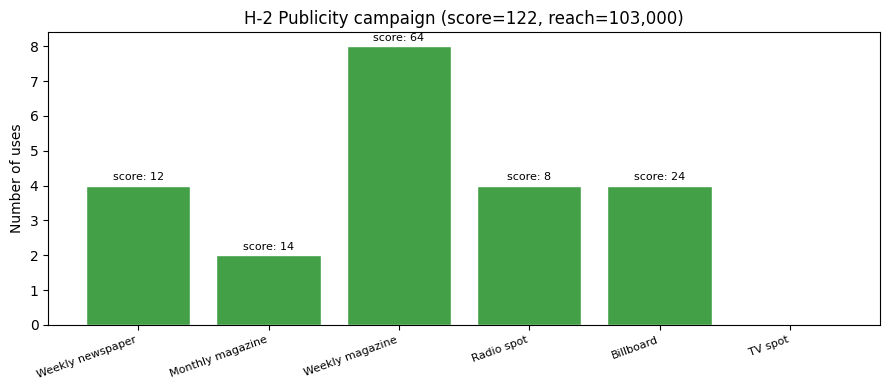

In [ ]:
if "sol_use" in locals():
    uses   = [round(sol_use.get(m, 0)) for m in range(1, 7)]
    scores = [SCORE[m] * uses[m-1] for m in range(1, 7)]
    colors = ["#43A047" if uses[m-1] > 0 else "#BDBDBD" for m in range(1, 7)]
    labels = [NAMES[m] for m in range(1, 7)]

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(range(6), uses, color=colors, edgecolor="white")
    for i, (u, s) in enumerate(zip(uses, scores)):
        if u > 0:
            ax.text(i, u + 0.1, f"score: {s}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(6))
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("Number of uses")
    ax.set_title(f"H-2 Publicity campaign (score={obj_val_h2:.0f}, reach={total_reach:,.0f})")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping publicity chart")

## H-3 Investment portfolio (LP)

*Applications Book Chapter H, Example 3*

> **Mosel model:** [`h3portf_p.mos`](models/economics_finance/h3portf_p.mos)

A financial consultant allocates 100,000 in capital across 6 shares. Each share investment must be between VMIN and VMAX. Technology shares are capped at 30% of capital; European shares must represent at least 50%. The model maximizes total expected return on investment.

**Sets:** $\text{SHARES} = \{1..6\}$, $\text{EU} \subseteq \text{SHARES}$, $\text{TECHNOLOGY} \subseteq \text{SHARES}$

**Parameters:** $\text{RET}_s$ - expected return (%); $\text{CAPITAL}$; $\text{MAXTECH}$; $\text{MINEU}$; $\text{VMIN}$; $\text{VMAX}$

**Decision variables:** $\mathit{buy}_s \geq 0$ - amount invested in share $s$

$$
\begin{align*}
\text{maximize}   \quad & \sum_s \frac{\text{RET}_s}{100} \cdot \mathit{buy}_s \\
\text{subject to} \quad & \sum_s \mathit{buy}_s = \text{CAPITAL} \\
                          & \sum_{s \in \text{TECHNOLOGY}} \mathit{buy}_s \leq \text{MAXTECH} \cdot \text{CAPITAL} \\
                          & \sum_{s \in \text{EU}} \mathit{buy}_s \geq \text{MINEU} \cdot \text{CAPITAL} \\
                          & \text{VMIN} \leq \mathit{buy}_s \leq \text{VMAX} \quad \forall\, s
\end{align*}
$$

The `EU` and `TECHNOLOGY` subset constraints use Python `set` objects passed via `input_data`. These are `set of integer` in Mosel (not used as array indices), so they can be injected directly from Python. Portfolio composition limits are passed as `exec_params`.

In [ ]:
RET        = {1: 5.3, 2: 6.2, 3: 5.1, 4: 4.9, 5: 6.5, 6: 3.4}
EU         = {2, 3, 5, 6}        # European shares
TECHNOLOGY = {1, 2, 3}           # Technology shares
CAPITAL    = 100_000
MAXTECH    = 0.30
MINEU      = 0.50
VMIN       = 5_000
VMAX       = 40_000

print(f"Expected returns (%): { {s: f'{r:.1f}' for s,r in RET.items()} }")
print(f"European shares: {EU}")
print(f"Technology shares: {TECHNOLOGY}")
print(f"Constraints: VMIN={VMIN:,}  VMAX={VMAX:,}  MAXTECH={MAXTECH:.0%}  MINEU={MINEU:.0%}")

Expected returns (%): {1: '5.3', 2: '6.2', 3: '5.1', 4: '4.9', 5: '6.5', 6: '3.4'}
European shares: {2, 3, 5, 6}
Technology shares: {1, 2, 3}
Constraints: VMIN=5,000  VMAX=40,000  MAXTECH=30%  MINEU=50%


Use the single execution command. `EU` and `TECHNOLOGY` are Python `set` objects, passed as `input_data` alongside the return array. Portfolio composition limits are set via `exec_params`.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/h3portf_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:",
                 "CAPITAL": CAPITAL, "MAXTECH": MAXTECH, "MINEU": MINEU,
                 "VMIN": VMIN, "VMAX": VMAX},
    input_data={"RET": RET, "EU": EU, "TECHNOLOGY": TECHNOLOGY},
)

if model.prob_status.is_solution_available:
    obj_val_h3 = output["obj_val"]
    sol_buy    = output["sol_buy"]

    print(f"Total expected return: {obj_val_h3:,.0f}")
    print()
    total_tech = sum(sol_buy.get(s, 0) for s in TECHNOLOGY)
    total_eu   = sum(sol_buy.get(s, 0) for s in EU)
    print(f"Technology cap: {total_tech:,.0f} / {MAXTECH*CAPITAL:,.0f}  (limit: {MAXTECH:.0%})")
    print(f"European min:   {total_eu:,.0f} / {MINEU*CAPITAL:,.0f}  (limit: {MINEU:.0%})")
    print()
    for s in range(1, 7):
        tag = []
        if s in EU:         tag.append("EU")
        if s in TECHNOLOGY: tag.append("Tech")
        label = f" ({', '.join(tag)})" if tag else ""
        print(f"  Share {s}{label}: {sol_buy.get(s, 0):>8,.0f}  (return: {RET[s]*sol_buy.get(s,0)/100:,.0f})")
else:
    print(f"No solution found ({model.prob_status})")

Total expected return: 5,755

Technology cap: 30,000 / 30,000  (limit: 30%)
European min:   70,000 / 50,000  (limit: 50%)

  Share 1 (Tech):    5,000  (return: 265)
  Share 2 (EU, Tech):   20,000  (return: 1,240)
  Share 3 (EU, Tech):    5,000  (return: 255)
  Share 4:   25,000  (return: 1,225)
  Share 5 (EU):   40,000  (return: 2,600)
  Share 6 (EU):    5,000  (return: 170)


Pie chart of portfolio allocation, with EU and Technology shares highlighted.

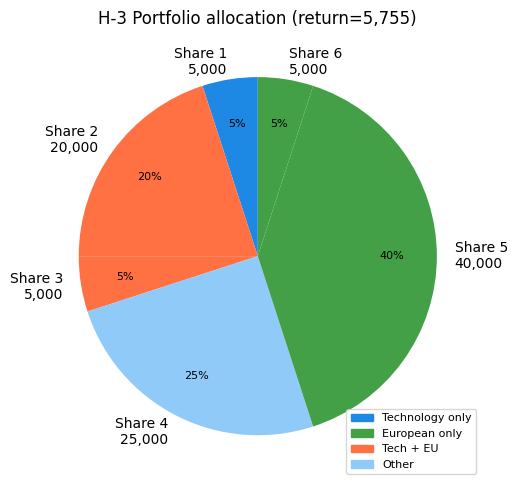

In [ ]:
if "sol_buy" in locals():
    allocs = [sol_buy.get(s, 0) for s in range(1, 7)]
    colors = []
    for s in range(1, 7):
        if s in TECHNOLOGY and s in EU:
            colors.append("#FF7043")
        elif s in TECHNOLOGY:
            colors.append("#1E88E5")
        elif s in EU:
            colors.append("#43A047")
        else:
            colors.append("#90CAF9")

    labels = [f"Share {s}\n{allocs[s-1]:,.0f}" for s in range(1, 7)]

    fig, ax = plt.subplots(figsize=(7, 5))
    wedges, texts, autotexts = ax.pie(
        allocs, labels=labels, colors=colors,
        autopct="%1.0f%%", startangle=90, pctdistance=0.75,
    )
    for at in autotexts:
        at.set_fontsize(8)

    tech_p = mpatches.Patch(color="#1E88E5", label="Technology only")
    eu_p   = mpatches.Patch(color="#43A047", label="European only")
    both_p = mpatches.Patch(color="#FF7043", label="Tech + EU")
    other_p = mpatches.Patch(color="#90CAF9", label="Other")
    ax.legend(handles=[tech_p, eu_p, both_p, other_p], fontsize=8,
              loc="lower right")
    ax.set_title(f"H-3 Portfolio allocation (return={obj_val_h3:,.0f})")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping portfolio chart")

## H-4 Retirement fund (MIP)

*Applications Book Chapter H, Example 4*

> **Mosel model:** [`h4retire_p.mos`](models/economics_finance/h4retire_p.mos)

A bank needs to finance a retirement scheme requiring fixed annual payments over 7 years. It can invest in three bond types: SNCF (5-year, 7%), Fujitsu (4-year, 7%), and Treasury (6-year, 6.5%). Bonds are purchased at the start of year 1 only; remaining cash earns 3.2% interest. The model minimizes the total capital required.

**Sets:** $\text{BONDS} = \{\text{SNCF}, \text{Fujitsu}, \text{Treasury}\}$, $\text{YEARS} = 1..7$

**Parameters:** $\text{DEM}_t$ - retirement payment in year $t$; $\text{VALUE}_b$, $\text{RATE}_b$, $\text{DUR}_b$ - bond characteristics; $\text{INTEREST}$ - cash rate

**Decision variables:** $\mathit{buy}_b \in \mathbb{Z}_{\geq 0}$ - bonds purchased; $\mathit{invest}_t \geq 0$ - cash invested in year $t$; $\mathit{capital}$ - total capital

$$
\begin{align*}
\text{minimize} \quad & \mathit{capital} \\
\text{s.t.} \quad & \mathit{capital} - \textstyle\sum_b \text{VALUE}_b \cdot \mathit{buy}_b - \mathit{invest}_1 = \text{DEM}_1 \\
                   & \textstyle\sum_{b:\, \text{DUR}_b+1 \geq t} \bigl(\text{RET}_b \cdot \mathit{buy}_b + [\text{DUR}_b+1=t]\,\text{VALUE}_b \cdot \mathit{buy}_b\bigr) + (1+r)\,\mathit{invest}_{t-1} - \mathit{invest}_t = \text{DEM}_t \quad \forall\, t \geq 2
\end{align*}
$$

Define bond characteristics and annual payment requirements in Python. The `BONDS` set of strings auto-populates from the `VALUE` dict keys.

In [ ]:
DEM      = {1: 1000, 2: 600, 3: 640, 4: 480, 5: 760, 6: 1020, 7: 950}
VALUE    = {"SNCF": 1.0, "Fujitsu": 0.8, "Treasury": 0.5}
RATE     = {"SNCF": 7.0, "Fujitsu": 7.0, "Treasury": 6.5}
DUR      = {"SNCF": 5,   "Fujitsu": 4,   "Treasury": 6}
INTEREST = 3.2

print("Bond characteristics:")
for b in VALUE:
    print(f"  {b}: price={VALUE[b]}, rate={RATE[b]}%, duration={DUR[b]} years")
print(f"\nAnnual payments: { {t: f'{v:,}' for t,v in DEM.items()} }")

Bond characteristics:
  SNCF: price=1.0, rate=7.0%, duration=5 years
  Fujitsu: price=0.8, rate=7.0%, duration=4 years
  Treasury: price=0.5, rate=6.5%, duration=6 years

Annual payments: {1: '1,000', 2: '600', 3: '640', 4: '480', 5: '760', 6: '1,020', 7: '950'}


Use the compile-load-run sequence to allow rerunning with different planning horizons or payment schedules. After solving, `sol_buy` contains bond quantities per type and `sol_invest` contains the cash invested each year.

In [ ]:
mp.compile_model(f"{MODELS}/h4retire_p.mos", f"{MODELS}/h4retire_p.bim")
model = mp.load_model(f"{MODELS}/h4retire_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"DEM": DEM, "VALUE": VALUE, "RATE": RATE, "DUR": DUR, "INTEREST": INTEREST},
)

if model.prob_status.is_solution_available:
    obj_val_h4  = output["obj_val"]
    sol_buy     = output["sol_buy"]
    sol_invest  = output["sol_invest"]
    sol_value   = output["VALUE"]

    print(f"Minimum capital required: {obj_val_h4:,.3f}")
    print()
    print("Bonds to purchase:")
    for b in VALUE:
        n = round(sol_buy.get(b, 0))
        cost = n * sol_value.get(b, VALUE[b])
        print(f"  {b}: {n:,} bonds  (cost: {cost:,.1f})")
    print()
    print("Cash investment by year:")
    for t in range(1, 7):
        print(f"  Year {t}: {sol_invest.get(t, 0):>10.3f}")
else:
    print(f"No solution found ({model.prob_status})")

Minimum capital required: 4,548.951

Bonds to purchase:
  SNCF: 899 bonds  (cost: 899.0)
  Fujitsu: 747 bonds  (cost: 597.6)
  Treasury: 1,783 bonds  (cost: 891.5)

Cash investment by year:
  Year 1:   1160.851
  Year 2:    760.708
  Year 3:    307.760
  Year 4:      0.318
  Year 5:      0.637
  Year 6:      0.535


Two-panel chart: (left) bond purchase cost breakdown; (right) cash flow timeline showing annual retirement payments and interest investment balance.

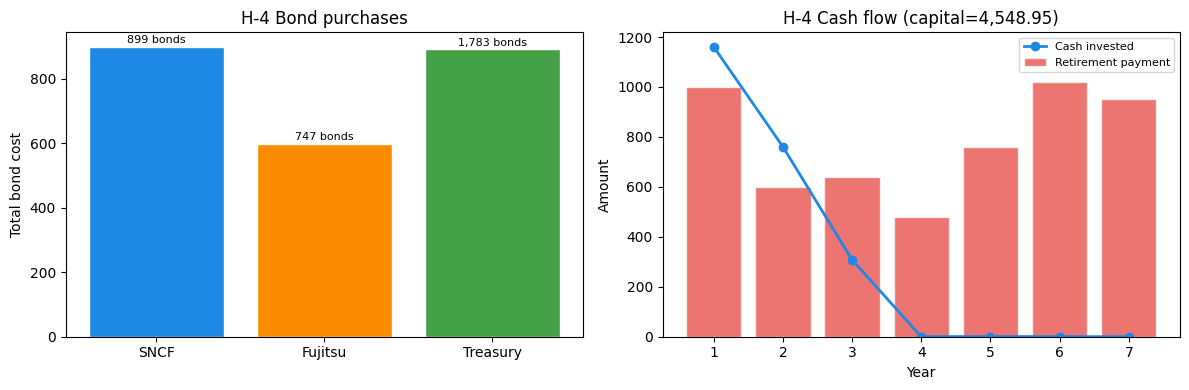

In [ ]:
if "sol_buy" in locals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: bond cost breakdown
    ax = axes[0]
    bond_colors = {"SNCF": "#1E88E5", "Fujitsu": "#FB8C00", "Treasury": "#43A047"}
    bond_names  = list(VALUE.keys())
    bond_costs  = [round(sol_buy.get(b, 0)) * VALUE[b] for b in bond_names]
    ax.bar(bond_names, bond_costs, color=[bond_colors[b] for b in bond_names], edgecolor="white")
    for i, (b, c) in enumerate(zip(bond_names, bond_costs)):
        n = round(sol_buy.get(b, 0))
        ax.text(i, c + 5, f"{n:,} bonds", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Total bond cost")
    ax.set_title("H-4 Bond purchases")

    # Right: annual cash flows
    ax2 = axes[1]
    years  = list(range(1, 8))
    invest = [sol_invest.get(t, 0) for t in years]
    demand = [DEM[t] for t in years]
    ax2.bar(years, demand,   color="#E53935", alpha=0.7, label="Retirement payment", edgecolor="white")
    ax2.plot(years, invest, marker="o", color="#1E88E5", linewidth=2, label="Cash invested")
    ax2.set_xlabel("Year")
    ax2.set_ylabel("Amount")
    ax2.set_title(f"H-4 Cash flow (capital={obj_val_h4:,.2f})")
    ax2.legend(fontsize=8)

    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping retirement charts")

## H-5 Family budget (LP)

*Applications Book Chapter H, Example 5*

A family earns a fixed monthly income plus an allowance. Regular expenses recur at different periodicities (monthly, bimonthly, semi-annual). Each month a minimum amount must be spent on hobbies; surplus income is saved and carries forward. The model maximizes total hobby spending over 12 months.

*Applications Book Chapter H, Example 5*

> **Mosel model:** [`h5budget_p.mos`](models/economics_finance/h5budget_p.mos)

**Note:** the original model reads `EXPENSE` and `FREQ` via the aliased block `[EXPENSE, FREQ] as 'PAYMENT'`. The adapted model reads them individually by name so Python can inject them directly.

**Sets:** $\text{MONTHS} = 1..12$, $\text{ITEMS}$ (expense categories, auto-populated)

**Parameters:** $\text{INCOME}$, $\text{ALLOW}$, $\text{HMIN}$; $\text{EXPENSE}_i$, $\text{FREQ}_i$ - amount and periodicity of expense category $i$

**Decision variables:** $\mathit{hobby}_m \geq \text{HMIN}$, $\mathit{saving}_m \geq 0$

$$
\begin{align*}
\text{maximize}   \quad & \sum_{m=1}^{12} \mathit{hobby}_m \\
\text{subject to} \quad & \sum_{i:\, m \bmod \text{FREQ}_i = 0} \text{EXPENSE}_i + \mathit{hobby}_m + \mathit{saving}_m \leq \text{INCOME} + \text{ALLOW} + \mathit{saving}_{m-1} \quad \forall\, m
\end{align*}
$$

Define expenses as string-keyed dicts for `EXPENSE` (amounts) and `FREQ` (periodicities in months). The `ITEMS` set of strings auto-populates from the `EXPENSE` dict keys. `INCOME`, `ALLOW`, and `HMIN` are scalars passed via `input_data`.

In [ ]:
EXPENSE = {"Living": 550, "Rent": 630, "Telephone": 135,
           "Electricity": 850, "Car": 340, "Tax": 100}
FREQ    = {"Living": 1, "Rent": 1, "Telephone": 2,
           "Electricity": 6, "Car": 1, "Tax": 4}
INCOME  = 1900
ALLOW   = 150
HMIN    = 165

print("Expense schedule:")
for item in EXPENSE:
    period = "monthly" if FREQ[item] == 1 else f"every {FREQ[item]} months"
    print(f"  {item}: {EXPENSE[item]:,} ({period})")
print(f"\nMonthly income: {INCOME:,} + allowance: {ALLOW:,}  |  Min hobby budget: {HMIN:,}")

Expense schedule:
  Living: 550 (monthly)
  Rent: 630 (monthly)
  Telephone: 135 (every 2 months)
  Electricity: 850 (every 6 months)
  Car: 340 (monthly)
  Tax: 100 (every 4 months)

Monthly income: 1,900 + allowance: 150  |  Min hobby budget: 165


Use the single execution command. The `ITEMS` set of strings auto-populates from the `EXPENSE` dict keys. The `mod` operator in the Mosel model handles the payment periodicity.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/h5budget_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"EXPENSE": EXPENSE, "FREQ": FREQ,
                "INCOME": INCOME, "ALLOW": ALLOW, "HMIN": HMIN},
)

if model.prob_status.is_solution_available:
    obj_val_h5  = output["obj_val"]
    sol_hobby   = output["sol_hobby"]
    sol_saving  = output["sol_saving"]

    print(f"Total hobby money over the year: {obj_val_h5:,.0f}")
    print()
    month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    print(f"{'Month':<6} {'Hobby':>7} {'Saving':>8}")
    for m in range(1, 13):
        print(f"{month_names[m-1]:<6} {sol_hobby.get(m,0):>7.0f} {sol_saving.get(m,0):>8.0f}")
else:
    print(f"No solution found ({model.prob_status})")

Total hobby money over the year: 3,550

Month    Hobby   Saving
Jan        165      365
Feb        165      595
Mar        165      960
Apr        165     1090
May        165     1455
Jun        165      835
Jul       1365        0
Aug        295        0
Sep        405      125
Oct        165      355
Nov        165      720
Dec        165        0


Monthly budget breakdown: stacked bars showing hobby spending and savings, with expense commitments annotated.

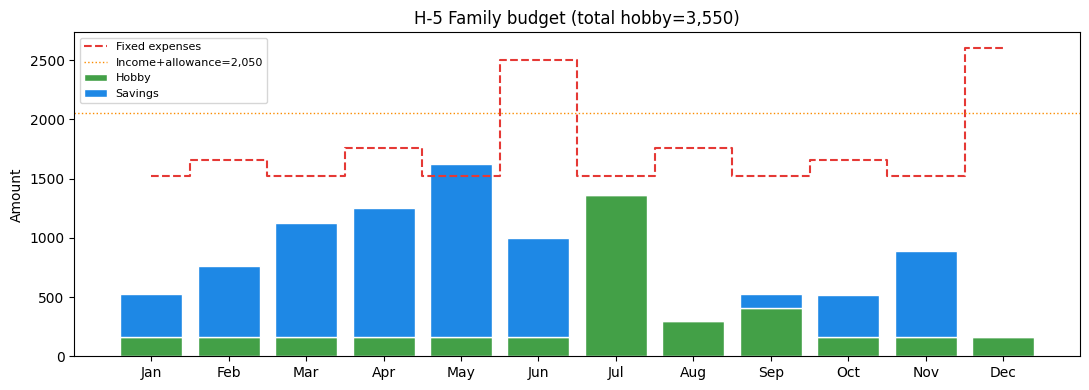

In [ ]:
if "sol_hobby" in locals():
    month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    hobby_vals  = [sol_hobby.get(m, 0) for m in range(1, 13)]
    saving_vals = [sol_saving.get(m, 0) for m in range(1, 13)]

    # Monthly fixed expenses
    monthly_exp = [sum(EXPENSE[i] for i in EXPENSE if m % FREQ[i] == 0)
                   for m in range(1, 13)]

    fig, ax = plt.subplots(figsize=(11, 4))
    x = range(12)
    ax.bar(x, hobby_vals,  label="Hobby",   color="#43A047", edgecolor="white")
    ax.bar(x, saving_vals, label="Savings", color="#1E88E5", edgecolor="white",
           bottom=hobby_vals)
    ax.step(x, monthly_exp, where="mid", color="#E53935", linewidth=1.5,
            linestyle="--", label="Fixed expenses")
    ax.axhline(INCOME + ALLOW, color="#FB8C00", linewidth=1, linestyle=":",
               label=f"Income+allowance={INCOME+ALLOW:,}")
    ax.set_xticks(range(12))
    ax.set_xticklabels(month_names)
    ax.set_ylabel("Amount")
    ax.set_title(f"H-5 Family budget (total hobby={obj_val_h5:,.0f})")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping budget chart")

## H-6 Company expansion (IP with LP relaxation)

*Applications Book Chapter H, Example 6*

> **Mosel model:** [`h6expand_p.mos`](models/economics_finance/h6expand_p.mos)

A company chooses from 5 candidate expansion projects over a 5-year horizon. Each project has annual costs and a 5-year profit. The model maximizes total profit subject to annual capital availability. The problem is solved first as an LP with `maximize(XPRS_LIN, Profit)`, then as the full MIP with `maximize(Profit)`. A `FORCED` parameter allows locking in a specific project for a third solve.

**Sets:** $\text{PROJECTS} = 1..5$, $\text{TIME} = 1..5$

**Parameters:** $\text{COST}_{p,t}$, $\text{CAP}_t$, $\text{RET}_p$; $\text{FORCED}$ - project to force (0 = none)

**Decision variables:** $\mathit{choose}_p \in \{0,1\}$ - 1 if project $p$ is selected

$$
\begin{align*}
\text{maximize}   \quad & \sum_p \text{RET}_p \cdot \mathit{choose}_p \\
\text{subject to} \quad & \sum_p \text{COST}_{p,t} \cdot \mathit{choose}_p \leq \text{CAP}_t \quad \forall\, t
\end{align*}
$$

Define the 5x5 cost matrix, annual capital limits, project returns, and project descriptions. All arrays are 1-indexed dicts.

In [ ]:
cost_raw = [
    [1.80, 2.40, 2.40, 1.80, 1.50],
    [1.20, 1.80, 2.40, 0.60, 0.50],
    [1.20, 1.00, 0.00, 0.48, 0.00],
    [1.40, 1.40, 1.20, 1.20, 1.20],
    [1.60, 2.10, 2.50, 2.00, 1.80],
]
COST  = {(p+1, t+1): cost_raw[p][t] for p in range(5) for t in range(5)}
CAP   = {1: 4.8, 2: 6.0, 3: 4.8, 4: 4.2, 5: 3.5}
RET   = {1: 10.8, 2: 4.8, 3: 3.2, 4: 4.44, 5: 12.25}
DESCR = {1: "Expand assembly line", 2: "Reorganize shop",
         3: "New painting facility", 4: "Concept car",
         5: "Reorganize logistics"}

cost_df = pd.DataFrame(cost_raw, index=[f"P{p}" for p in range(1,6)],
                       columns=[f"Year {t}" for t in range(1,6)])
cost_df.index.name = "Project"
print("Annual costs per project:")
print(cost_df.to_string())
print(f"\nExpected returns: { {p: f'{r:.2f}M' for p,r in RET.items()} }")

Annual costs per project:
         Year 1  Year 2  Year 3  Year 4  Year 5
Project                                        
P1          1.8     2.4     2.4    1.80     1.5
P2          1.2     1.8     2.4    0.60     0.5
P3          1.2     1.0     0.0    0.48     0.0
P4          1.4     1.4     1.2    1.20     1.2
P5          1.6     2.1     2.5    2.00     1.8

Expected returns: {1: '10.80M', 2: '4.80M', 3: '3.20M', 4: '4.44M', 5: '12.25M'}


### LP relaxation and MIP comparison

The model is compiled once and run twice: first with `FORCED=0` (returns LP and MIP results in a single call), then with `FORCED=1` to lock in project 1 and observe how it changes the optimal portfolio.

Calling `maximize(XPRS_LIN, Profit)` solves the problem first as an LP, ignoring any MIP information; the model then saves the LP bound and solves the full MIP with `maximize(Profit)`. This pattern is useful for bounding analysis and warm-starting.

In [ ]:
mp.compile_model(f"{MODELS}/h6expand_p.mos", f"{MODELS}/h6expand_p.bim")
model = mp.load_model(f"{MODELS}/h6expand_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

common_data = {"COST": COST, "CAP": CAP, "RET": RET, "DESCR": DESCR}
common_params = {"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"}

# Run with no forcing (returns LP + MIP in a single call)
out0 = model.run(exec_params={**common_params, "FORCED": 0}, input_data=common_data)

# Run with FORCED=1 (force project 1 into MIP)
out1 = model.run(exec_params={**common_params, "FORCED": 1}, input_data=common_data)

results = {}
for label, out in [("No forcing", out0), ("Force project 1", out1)]:
    if model.prob_status.is_solution_available:
        chosen = [p for p in range(1, 6) if round(out.get("sol_choose", {}).get(p, 0)) > 0]
        results[label] = {"obj": out["obj_val"], "projects": chosen}
        print(f"{label}: total profit = {out['obj_val']:.2f}")
        for p in chosen:
            print(f"    {p}. {DESCR[p]}")
    print()

if out0 is not None:
    print(f"LP relaxation: {out0['obj_lp']:.3f}  |  MIP: {out0['obj_mip']:.2f}")

No forcing: total profit = 19.89
    3. New painting facility
    4. Concept car
    5. Reorganize logistics

Force project 1: total profit = 18.80
    1. Expand assembly line
    2. Reorganize shop
    3. New painting facility

LP relaxation: 19.890  |  MIP: 19.89


Bar chart comparing LP relaxation, MIP, and forced MIP objective values. Project selection indicators shown below.

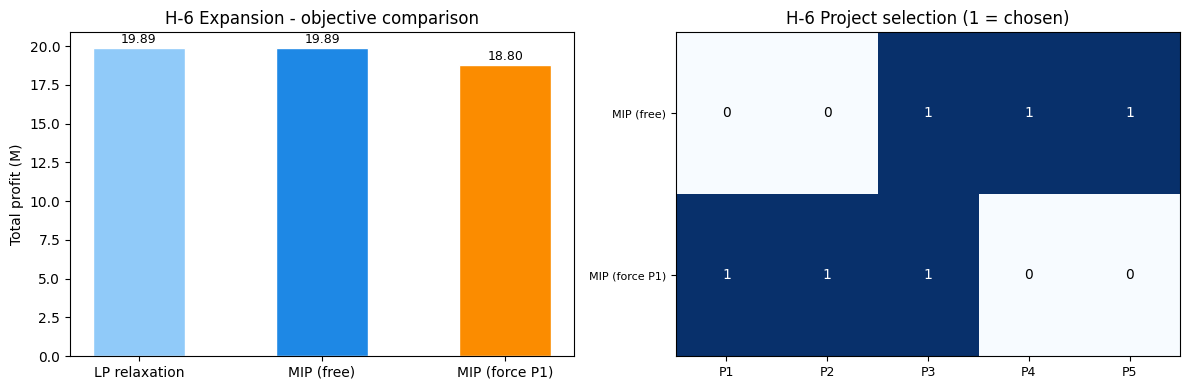

In [ ]:
if out0 is not None and out1 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: objective comparison
    ax = axes[0]
    labels_bar = ["LP relaxation", "MIP (free)", "MIP (force P1)"]
    values_bar = [out0["obj_lp"], out0["obj_mip"], out1["obj_val"]]
    colors_bar = ["#90CAF9", "#1E88E5", "#FB8C00"]
    bars = ax.bar(labels_bar, values_bar, color=colors_bar, edgecolor="white", width=0.5)
    for bar, v in zip(bars, values_bar):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.1,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Total profit (M)")
    ax.set_title("H-6 Expansion - objective comparison")

    # Right: project selection heatmap
    ax2 = axes[1]
    scenarios  = ["MIP (free)", "MIP (force P1)"]
    out_list   = [out0, out1]
    sel_matrix = [[round(o.get("sol_choose", {}).get(p, 0)) for p in range(1, 6)] for o in out_list]
    im = ax2.imshow(sel_matrix, cmap="Blues", aspect="auto", vmin=0, vmax=1)
    ax2.set_xticks(range(5))
    ax2.set_xticklabels([f"P{p}" for p in range(1, 6)], fontsize=9)
    ax2.set_yticks(range(2))
    ax2.set_yticklabels(scenarios, fontsize=8)
    for i in range(2):
        for j in range(5):
            ax2.text(j, i, str(sel_matrix[i][j]), ha="center", va="center", fontsize=10,
                     color="white" if sel_matrix[i][j] > 0.5 else "black")
    ax2.set_title("H-6 Project selection (1 = chosen)")

    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping expansion charts")

## H-7 Mean-variance portfolio (QP/MIQP)

*Applications Book Chapter H, Example 7*

> **Mosel model:** [`h7qportf_p.mos`](models/economics_finance/h7qportf_p.mos)

An investor allocates capital across 4 securities: hardware, software, show-biz, and T-bills. The model minimizes portfolio variance (risk) subject to achieving a minimum target yield. Two variants are solved: (1) a QP with no asset limit, (2) a MIQP restricting the portfolio to at most `MAXASSETS` securities. The quadratic objective requires the `mmnl` Mosel module.

**Sets:** $\text{SECS} = \{1..4\}$

**Parameters:** $\text{RET}_s$ - expected yield; $\text{VAR}_{s,t}$ - variance/covariance matrix; $\text{TARGET}$ - minimum yield; $\text{MAXASSETS}$ - max securities in MIQP

**Decision variables:** $\mathit{frac}_s \in [0,1]$ - fraction of capital in security $s$; $\mathit{buy}_s \in \{0,1\}$ (MIQP only)

$$
\begin{align*}
\text{minimize}   \quad & \sum_{s,t} \text{VAR}_{s,t} \cdot \mathit{frac}_s \cdot \mathit{frac}_t \\
\text{subject to} \quad & \sum_s \mathit{frac}_s = 1 \\
                          & \sum_s \text{RET}_s \cdot \mathit{frac}_s \geq \text{TARGET} \\
                          & \mathit{frac}_s \leq \mathit{buy}_s \quad \forall\, s \quad \text{(MIQP only)}
\end{align*}
$$

Define the return vector and variance/covariance matrix. T-bills have zero variance and a fixed 7% yield, making them the natural risk-free anchor. The target yield and maximum assets are overridable via `exec_params`.

In [ ]:
NAMES = {1: "Hardware", 2: "Software", 3: "Show-biz", 4: "T-bills"}
RET   = {1: 8, 2: 9, 3: 12, 4: 7}
VAR   = {(1,1):  4, (1,2):  3, (1,3): -1, (1,4): 0,
         (2,1):  3, (2,2):  6, (2,3):  1, (2,4): 0,
         (3,1): -1, (3,2):  1, (3,3): 10, (3,4): 0,
         (4,1):  0, (4,2):  0, (4,3):  0, (4,4): 0}
TARGET    = 7.0
MAXASSETS = 4

var_df = pd.DataFrame(
    {NAMES[s]: [VAR[(s,t)] for t in range(1,5)] for s in range(1,5)},
    index=[NAMES[t] for t in range(1,5)],
)
print("Variance/covariance matrix:")
print(var_df.to_string())
print(f"\nExpected yields: { {NAMES[s]: f'{RET[s]}%' for s in range(1,5)} }")

Variance/covariance matrix:
          Hardware  Software  Show-biz  T-bills
Hardware         4         3        -1        0
Software         3         6         1        0
Show-biz        -1         1        10        0
T-bills          0         0         0        0

Expected yields: {'Hardware': '8%', 'Software': '9%', 'Show-biz': '12%', 'T-bills': '7%'}


Use the compile-load-run sequence to enable TARGET sensitivity analysis. The model runs both the QP and MIQP variants in a single call and returns `obj_qp`, `qp_frac`, `obj_miqp`, and `miqp_frac`.

In [ ]:
mp.compile_model(f"{MODELS}/h7qportf_p.mos", f"{MODELS}/h7qportf_p.bim")
model = mp.load_model(f"{MODELS}/h7qportf_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:",
                 "TARGET": TARGET, "MAXASSETS": MAXASSETS},
    input_data={"RET": RET, "VAR": VAR},
)

if model.prob_status.is_solution_available:
    obj_qp    = output["obj_qp"]
    obj_miqp  = output["obj_miqp"]
    qp_frac   = output["qp_frac"]
    miqp_frac = output["miqp_frac"]
    sol_buy   = output["sol_buy"]

    print(f"QP  (unlimited assets):      variance = {obj_qp:.6f}")
    for s in range(1, 5):
        pct = qp_frac.get(s, 0) * 100
        if pct > 0.01:
            print(f"    {NAMES[s]}: {pct:.2f}%")

    print(f"\nMIQP (max {MAXASSETS} assets): variance = {obj_miqp:.6f}")
    for s in range(1, 5):
        pct = miqp_frac.get(s, 0) * 100
        if pct > 0.01:
            print(f"    {NAMES[s]}: {pct:.2f}%")
else:
    print(f"No solution found ({model.prob_status})")

QP  (unlimited assets):      variance = 0.000000
    Hardware: 0.01%
    Show-biz: 0.01%
    T-bills: 99.96%

MIQP (max 4 assets): variance = 0.000000
    T-bills: 100.00%


### Efficient frontier: variance vs target yield

The model is already compiled and loaded. Run it multiple times with increasing `TARGET` values to trace the efficient frontier: the minimum-variance portfolio for each required yield level. As the target yield increases beyond 7% (T-bills), the optimizer must include riskier assets, driving up variance.

In [ ]:
targets  = [7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 11.0, 12.0]
frontier = []

for tgt in targets:
    out = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:",
                     "TARGET": tgt, "MAXASSETS": 4},
        input_data={"RET": RET, "VAR": VAR},
    )
    if model.prob_status.is_solution_available:
        fracs = {NAMES[s]: round(out["qp_frac"].get(s, 0) * 100, 2) for s in range(1, 5)}
        frontier.append({"Target yield (%)": tgt, "Min variance": out["obj_qp"], **fracs})
    else:
        print(f"No solution for TARGET={tgt}")

frontier_df = pd.DataFrame(frontier).set_index("Target yield (%)")
print("Efficient frontier (QP):")
print(frontier_df.to_string(float_format="{:.4f}".format))

Efficient frontier (QP):
                  Min variance  Hardware  Software  Show-biz  T-bills
Target yield (%)                                                     
7.0                     0.0000    0.0100    0.0100    0.0100  99.9600
7.5                     0.0805    5.0500    1.4400    8.4100  85.1000
8.0                     0.3221   10.1000    2.8900   16.8300  70.1900
8.5                     0.7248   15.1400    4.3300   25.2400  55.2900
9.0                     1.2885   20.1900    5.7700   33.6500  40.3800
9.5                     2.0132   25.2400    7.2100   42.0700  25.4800
10.0                    2.8990   30.2900    8.6500   50.4800  10.5800
11.0                    5.4286   14.2900   14.2900   71.4300   0.0000
12.0                   10.0000    0.0000    0.0000  100.0000   0.0000


Efficient frontier plot and portfolio composition heatmap showing how allocations shift as the target yield increases.

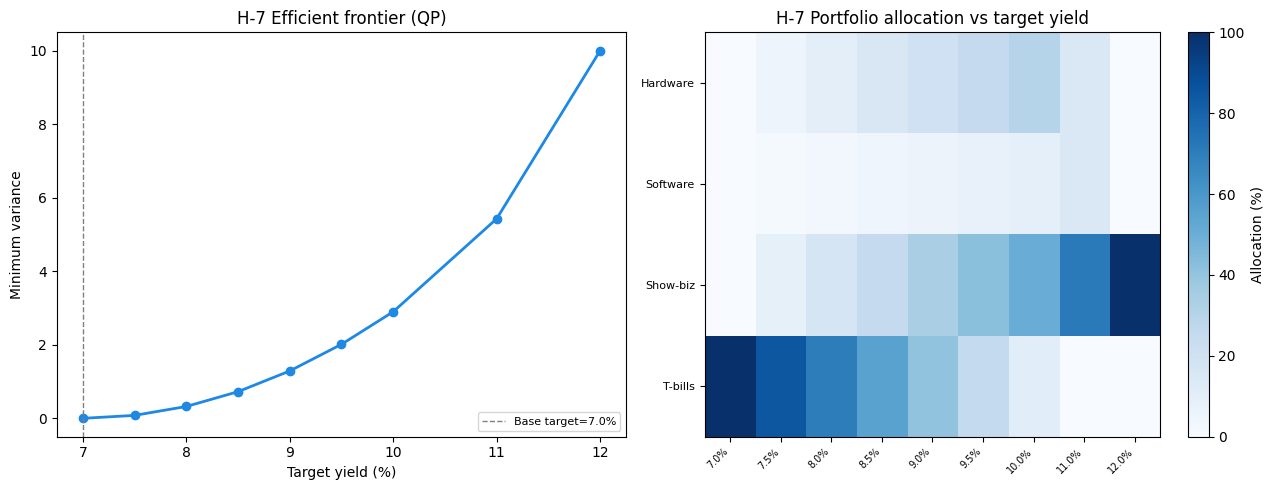

In [ ]:
if frontier_df is not None and not frontier_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: efficient frontier curve
    ax = axes[0]
    ax.plot(frontier_df.index, frontier_df["Min variance"],
            marker="o", color="#1E88E5", linewidth=2)
    ax.axvline(TARGET, color="gray", linestyle="--", linewidth=1,
               label=f"Base target={TARGET}%")
    ax.set_xlabel("Target yield (%)")
    ax.set_ylabel("Minimum variance")
    ax.set_title("H-7 Efficient frontier (QP)")
    ax.legend(fontsize=8)

    # Right: portfolio composition heatmap
    ax2 = axes[1]
    comp_cols = [NAMES[s] for s in range(1, 5)]
    comp = frontier_df[comp_cols].values
    im = ax2.imshow(comp.T, cmap="Blues", aspect="auto", vmin=0, vmax=100)
    plt.colorbar(im, ax=ax2, label="Allocation (%)")
    ax2.set_xticks(range(len(targets)))
    ax2.set_xticklabels([f"{t:.1f}%" for t in targets], rotation=45, ha="right", fontsize=7)
    ax2.set_yticks(range(4))
    ax2.set_yticklabels(comp_cols, fontsize=8)
    ax2.set_title("H-7 Portfolio allocation vs target yield")

    plt.tight_layout(); plt.show()
else:
    print("No frontier data available - skipping charts")